# Brent/WTI Statistical Arbitrage — Corrected Evaluation

Mean-reversion pairs trade on Brent (`BZ=F`) and WTI (`CL=F`) crude futures.
A robust Kalman filter estimates a time-varying hedge ratio; trades trigger on
rolling z-scores of the residual spread.

This version fixes five issues in the original notebook. Each fix is marked
`[FIX n]` in the code:

1. **Train/test split** — all reported performance comes from the out-of-sample
   test slice only (the original ran one pass over the full history).
2. **Return construction** — the hedge ratio is in *price* space, so it must be
   converted before use in *return* space (the original applied it directly).
3. **Transaction costs** — charged per unit of position change, at a more
   realistic per-trade level.
4. **Sharpe** — reported with time-in-market and an exit band, and compared
   in-sample vs out-of-sample so the figure can't be quietly inflated.
5. **Cointegration test** — Engle–Granger + ADF on the training set before trading.


## Imports

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import coint, adfuller


## Data
Longer history than the original (2018–2025) so there is enough data for a genuine train/test split.

In [5]:
def get_data(start="2018-01-01", end="2025-01-01"):
    tickers = ["CL=F", "BZ=F"]
    data = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
    return data.dropna()

df = get_data()
print("Rows:", len(df), "from", df.index.min().date(), "to", df.index.max().date())
df.tail()


[*********************100%***********************]  2 of 2 completed

Rows: 1761 from 2018-01-02 to 2024-12-31


Ticker,BZ=F,CL=F
Date,,
2024-12-24,73.580002,70.099998
2024-12-26,73.260002,69.620003
2024-12-27,74.169998,70.599998
2024-12-30,74.389999,70.989998
2024-12-31,74.639999,71.720001


## Tail diagnostics
Check for fat tails / skew before assuming Gaussian behaviour (kept from the original — this part was sound).

WTI daily return diagnostics:
  excess_kurtosis: 993.6208
  skew: -28.5699
  jarque_bera_p: 0.0000


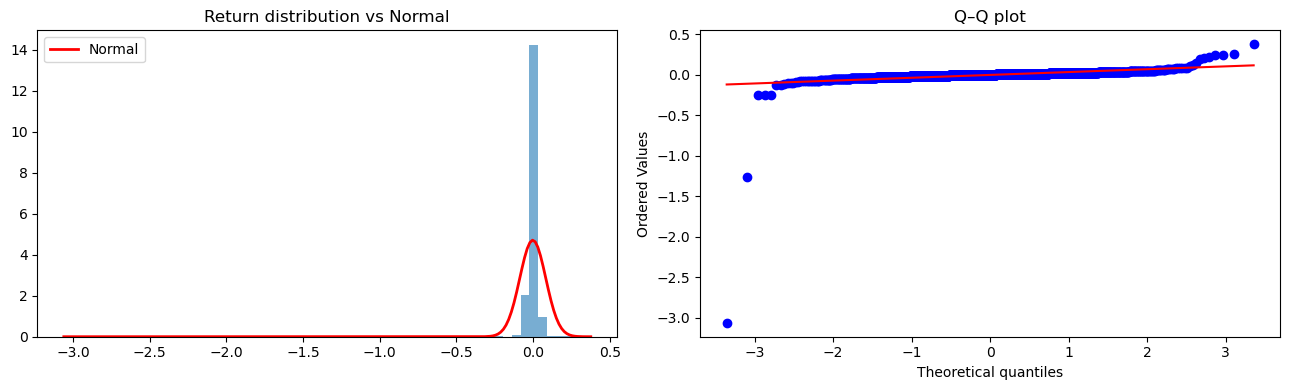

In [7]:
def tail_stats(returns):
    r = returns.dropna()
    return {
        "excess_kurtosis": float(r.kurtosis()),
        "skew": float(r.skew()),
        "jarque_bera_p": float(stats.jarque_bera(r)[1]),
    }

wti_ret = df["CL=F"].pct_change()
print("WTI daily return diagnostics:")
for k, v in tail_stats(wti_ret).items():
    print(f"  {k}: {v:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
r = wti_ret.dropna()
ax[0].hist(r, bins=60, density=True, alpha=0.6)
x = np.linspace(r.min(), r.max(), 200)
ax[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r", lw=2, label="Normal")
ax[0].set_title("Return distribution vs Normal"); ax[0].legend()
stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q–Q plot")
plt.tight_layout(); plt.show()


## [FIX 5] Cointegration test (training set only)
Confirm the pair is actually cointegrated on the in-sample window before trading it out-of-sample.

In [9]:
TRAIN_FRAC = 0.6
split = int(len(df) * TRAIN_FRAC)
train = df.iloc[:split]

def cointegration_test(train, x_col, y_col):
    score, pval, _ = coint(train[y_col], train[x_col])
    beta = np.polyfit(train[x_col], train[y_col], 1)[0]
    resid = train[y_col] - beta * train[x_col]
    adf_p = adfuller(resid)[1]
    return {"engle_granger_p": float(pval),
            "adf_resid_p": float(adf_p),
            "ols_beta_train": float(beta)}

print("Cointegration (TRAIN only):")
for k, v in cointegration_test(train, "CL=F", "BZ=F").items():
    print(f"  {k}: {v:.4f}")


Cointegration (TRAIN only):
  engle_granger_p: 0.0606
  adf_resid_p: 0.0169
  ols_beta_train: 0.9717


## Robust Kalman hedge-ratio filter
State = [beta, intercept]. Innovations clipped at 3σ to limit the effect of outliers (kept from the original — sound).

In [11]:
def kalman_hedge_ratio(x, y, Q_scale=1e-5, R=0.01, clip_sigma=3.0):
    state = np.zeros(2)          # [beta, intercept]
    P = np.eye(2)
    Q = np.eye(2) * Q_scale
    betas, preds = [], []
    for t in range(len(y)):
        P = P + Q
        H = np.array([x[t], 1.0]).reshape(1, 2)
        pred = (H @ state)[0]
        innov = y[t] - pred
        S = (H @ P @ H.T + R)[0, 0]
        sigma = np.sqrt(S)
        if abs(innov / sigma) > clip_sigma:           # robust clip
            innov = np.sign(innov) * clip_sigma * sigma
        K = (P @ H.T / S).flatten()
        state = state + K * innov
        P = (np.eye(2) - np.outer(K, H)) @ P
        betas.append(state[0]); preds.append(pred)
    return np.array(betas), np.array(preds)


## Strategy + honest backtest

- **[FIX 1]** 60/40 train/test split; everything reported uses the test slice.
- **[FIX 2]** Dollar-neutral return: beta is in price space, so the return-space
  weight on `x` is `beta * (x_price / y_price)`.
- **[FIX 3]** Cost charged on absolute position change, per unit.
- **[FIX 4]** Exit band (`exit_z`) so the book goes flat instead of always holding;
  time-in-market reported alongside Sharpe.

In [13]:
def backtest(df, x_col, y_col, train_frac=0.6,
             entry_z=2.0, exit_z=0.5, roll=20, cost_per_unit=0.0005):
    df = df.copy()
    x = df[x_col].values
    y = df[y_col].values

    betas, preds = kalman_hedge_ratio(x, y)
    df["beta"] = betas
    df["spread"] = y - preds
    df["z"] = ((df["spread"] - df["spread"].rolling(roll).mean())
               / df["spread"].rolling(roll).std())

    n = len(df)
    split = int(n * train_frac)
    df["is_test"] = np.arange(n) >= split

    # position with entry/exit bands
    pos = np.zeros(n); cur = 0.0; z = df["z"].values
    for t in range(n):
        if np.isnan(z[t]):
            cur = 0.0
        elif cur == 0.0:
            if z[t] > entry_z:    cur = -1.0
            elif z[t] < -entry_z: cur = 1.0
        else:
            if abs(z[t]) < exit_z:
                cur = 0.0
        pos[t] = cur
    df["position"] = pos

    # [FIX 2] dollar-neutral return
    pct_x = df[x_col].pct_change()
    pct_y = df[y_col].pct_change()
    w_x = df["beta"].shift(1) * (df[x_col].shift(1) / df[y_col].shift(1))
    gross = df["position"].shift(1) * (pct_y - w_x * pct_x)

    # [FIX 3] costs on position change
    turns = df["position"].diff().abs().fillna(0)
    df["ret"] = gross - turns * cost_per_unit
    return df

full = backtest(df, "CL=F", "BZ=F", train_frac=TRAIN_FRAC)
full[["beta", "spread", "z", "position"]].tail()


Ticker,beta,spread,z,position
Date,,,,
2024-12-24,0.962870,0.119726,0.458758,0.0
2024-12-26,0.964820,0.159818,0.540514,0.0
2024-12-27,0.964679,-0.011631,0.074840,0.0
2024-12-30,0.962774,-0.157918,-0.237099,0.0
2024-12-31,0.957073,-0.475700,-1.888098,0.0


## Performance — out-of-sample only

In [15]:
def summary(ret, position):
    r = ret.dropna()
    days = len(r)
    in_market = (position.reindex(r.index).fillna(0) != 0).mean()
    ann = np.sqrt(252)
    sharpe = (r.mean() / r.std() * ann) if r.std() > 0 else np.nan
    cum = float((1 + r.fillna(0)).prod())
    curve = (1 + r.fillna(0)).cumprod()
    dd = float((curve / curve.cummax() - 1).min())
    n_trades = int((position.reindex(r.index).fillna(0).diff().abs() > 0).sum())
    ann_ret = cum ** (252 / max(days, 1)) - 1
    return {
        "OOS_days": days,
        "time_in_market_pct": round(100 * in_market, 1),
        "OOS_sharpe_annualised": round(float(sharpe), 3),
        "OOS_cum_return_x": round(cum, 4),
        "OOS_annualised_return_pct": round(100 * ann_ret, 2),
        "OOS_max_drawdown_pct": round(100 * dd, 2),
        "OOS_num_trades": n_trades,
    }

test = full[full["is_test"]]
print("=== SUMMARY (out-of-sample) ===")
for k, v in summary(test["ret"], test["position"]).items():
    print(f"  {k}: {v}")


=== SUMMARY (out-of-sample) ===
  OOS_days: 705
  time_in_market_pct: 12.9
  OOS_sharpe_annualised: 1.601
  OOS_cum_return_x: 1.2881
  OOS_annualised_return_pct: 9.47
  OOS_max_drawdown_pct: -1.52
  OOS_num_trades: 70


## In-sample vs out-of-sample check
If out-of-sample Sharpe collapses relative to in-sample, the original 1.81 was in-sample overfit. This is the number to look at honestly.

In-sample  Sharpe: 0.040
Out-of-sample Sharpe: 1.601


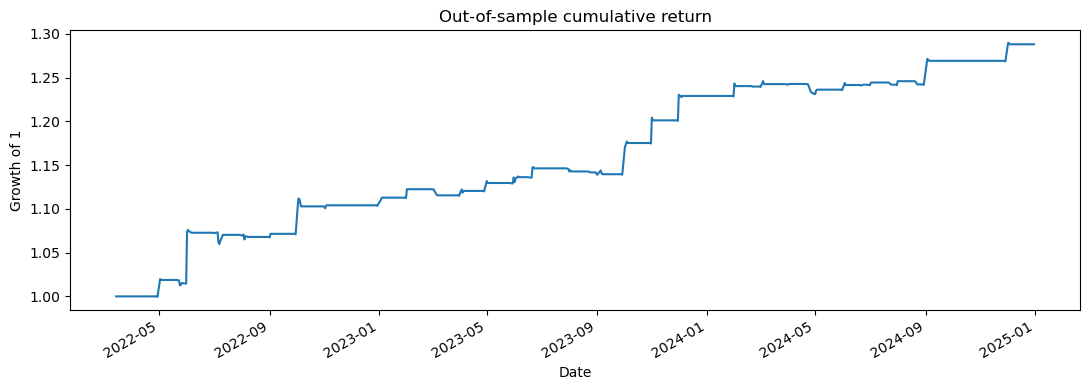

In [17]:
is_r = full.loc[~full["is_test"], "ret"].dropna()
is_sharpe = is_r.mean() / is_r.std() * np.sqrt(252) if is_r.std() > 0 else np.nan
oos_r = test["ret"].dropna()
oos_sharpe = oos_r.mean() / oos_r.std() * np.sqrt(252) if oos_r.std() > 0 else np.nan
print(f"In-sample  Sharpe: {is_sharpe:.3f}")
print(f"Out-of-sample Sharpe: {oos_sharpe:.3f}")

# Out-of-sample equity curve
curve = (1 + test["ret"].fillna(0)).cumprod()
curve.plot(figsize=(11, 4), title="Out-of-sample cumulative return")
plt.ylabel("Growth of 1"); plt.tight_layout(); plt.show()
